In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# open the files
mca_df = pd.read_csv('../data/auxiliary/mca_ai_measurements.csv')

median_aioe = mca_df['AIOE'].median()
median_comple = mca_df['Complementarity'].median()

def classify_by_ai_risk(job, threshold_aioe=median_aioe, threshold_comple=median_comple):
    job_aioe, job_comple = job['AIOE'], job['Complementarity']
    if job_aioe < threshold_aioe:
        return 'Not Affected'
    elif job_comple < threshold_comple:
        return 'Automated'
    else:
        return 'Augmented'

mca_df['AI Risk Classification'] = mca_df.apply(classify_by_ai_risk, axis=1)

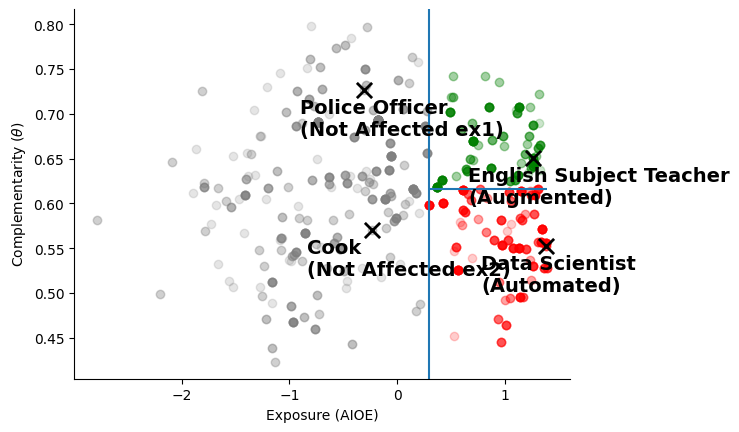

In [12]:
is_not_affected = mca_df['AI Risk Classification'] == 'Not Affected'
is_automated = mca_df['AI Risk Classification'] == 'Automated'
is_augmented = mca_df['AI Risk Classification'] == 'Augmented'

plt.scatter(mca_df[is_not_affected].AIOE, mca_df[is_not_affected].Complementarity, color='gray', alpha=0.2)
plt.scatter(mca_df[is_automated].AIOE, mca_df[is_automated].Complementarity, color='red',alpha=0.2)
plt.scatter(mca_df[is_augmented].AIOE, mca_df[is_augmented].Complementarity, color='green',alpha=0.2)

rep_jobs = {
    "Not Affected ex1":  {"idx": 428, "title": "Police Officer"},
    "Not Affected ex2":  {"idx": 787, "title": "Cook"},
    "Augmented": {"idx": 479, "title": "English Subject Teacher"},
    "Automated": {"idx": 544, "title": "Data Scientist"}
}

# Add chosen representative jobs
for c, job in rep_jobs.items():
    row = mca_df.loc[job["idx"]]
    plt.scatter(row['AIOE'], row['Complementarity'],
                marker='x', color='black', s=120, linewidths=2)
    plt.text(row['AIOE']-0.6, row['Complementarity']-0.05,
             f"{job['title']}\n({c})", fontsize=14, color='black',
             fontweight='bold')
    
plt.axvline(median_aioe)
plt.hlines(median_comple, xmin=median_aioe, xmax=mca_df.AIOE.max())

plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel('Exposure (AIOE)')
plt.ylabel(r'Complementarity ($\theta$)')
plt.show()

In [5]:
mca_df.to_csv('../data/FINAL_mca_data.csv')

In [6]:
mca_df['AI Risk Classification'].value_counts(normalize=True)

AI Risk Classification
Not Affected    0.495222
Automated       0.287576
Augmented       0.217202
Name: proportion, dtype: float64

In [7]:
mca_df.loc[[428, 787, 479, 544]]

,Job Title,Educational Qualification,Job Sector,Educational Pathway,HEI with PRC Exam,Some HEI,Job Subsector,PSOC Code,ISCO Code,SOC Code,SOC Title,SOC Codes,SOC Titles,AIOE,Complementarity,AI Risk Classification
428,Police Officer,Bachelor of Science in Police Administration,Public Administration and Defense; Compulsory ...,Higher Education,No,No,Public administration and defense; compulsory ...,5412,5412,33-3051.00,Police and Sheriff's Patrol Officers,"['33-1012.00', '33-3051.00', '33-3051.04', '33...",['First-Line Supervisors of Police and Detecti...,-0.305100,0.726389,Not Affected
787,Cook,Bachelor of Restaurant Management,Accommodation and Food Service Activities,Not Higher Education,No,No,Event catering and other food service activities,5120,5120,35-2015.00,"Cooks, Short Order","['35-1012.00', '35-2012.00', '35-2013.00', '35...",['First-Line Supervisors of Food Preparation a...,-0.237220,0.570000,Not Affected
479,English Subject Teacher,Bachelor of Secondary Education major in English,Education,Higher Education,Yes,No,"Primary/elementary education, Secondary/high s...",2353,2353,25-3011.00,"Adult Basic Education, Adult Secondary Educati...","['25-3011.00', '25-3021.00', '25-3099.00']","['Adult Basic Education, Adult Secondary Educa...",1.258243,0.650556,Augmented
544,Data Scientist,NaN,Information and Communication,Higher Education,No,No,"Data processing, hosting and related activitie...",3314,3314,15-2099.01,Bioinformatics Technicians,"['15-2099.00', '15-2099.01', '15-2099.00', '15...","['Mathematical Science Occupations, All Other'...",1.382653,0.551944,Automated
